# Visualisation d'un dataset BSS

Charge une scène depuis son manifeste, affiche ses métadonnées, ses signaux temporels et les spectrogrammes des sources et du mélange reçu par les microphones.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt

# Recherche la racine du dépôt, que le notebook soit lancé depuis Beluga
# ou depuis BSS/Dataset.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'BSS').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'BSS').is_dir():
    raise FileNotFoundError('Impossible de trouver la racine du dépôt Beluga.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from BSS.Dataset import load_scene

In [3]:
# Paramètres à adapter
dataset_root = repo_root / 'BSS' / 'Dataset' / 'generated' / 'boat_and_whistle_v1'
split = 'train'
scene_index = 1

In [4]:
manifest_path = dataset_root / split / 'manifest.jsonl'
with manifest_path.open(encoding='utf-8') as manifest:
    records = [json.loads(line) for line in manifest if line.strip()]

if not records:
    raise ValueError(f'Le manifeste {manifest_path} est vide.')
if not 0 <= scene_index < len(records):
    raise IndexError(f'scene_index doit être compris entre 0 et {len(records) - 1}.')

record = records[scene_index]
scene_path = manifest_path.parent / record['path']
scene = load_scene(scene_path)

print(f"Scène : {record['id']}")
print(f"Fichier : {scene_path}")
print(f"Seed : {record['seed']}")
print(f"Sources : {scene.sources.data.shape}")
print(f"Mélange : {scene.mixed.data.shape}")
print(f"Fréquence d'échantillonnage : {scene.metadata.fs} Hz")
scene.metadata

Scène : train_000001
Fichier : C:\Users\BORDERIES\Desktop\Cours\Stage canada\Beluga\BSS\Dataset\generated\boat_and_whistle_v1\train\scene_000001.npz
Seed : 471
Sources : (2, 460800)
Mélange : (4, 460800)
Fréquence d'échantillonnage : 384000 Hz


AudioSceneMetadata(fs=384000, duration=1.2, n_sources=2, n_mics=4, source_composites=[CompositeSignalMetadata(placements=[SignalPlacementMetadata(signal_type='large_ship_noise', signal_params={'time_duration': 9.676562014857344, 'shaft_rotation_frequency': 1.7386541707456873, 'propeller_blade_count': 5, 'tonal_harmonic_count': 4, 'tonal_decay': 1.0003213638178021, 'engine_cylinder_count': 12, 'engine_harmonic_count': 5, 'engine_harmonic_decay': 1.0794274088486284, 'cavitation_peak_frequency': 80.77733092604998, 'low_frequency_slope': 1.6593538506436356, 'high_frequency_slope': 1.0119674638151939, 'modulation_frequency': 3.456117093197589, 'modulation_depth': 0.3722913848265803, 'tonal_mix': 0.27140191418960535, 'engine_mix': 0.41902590981167565, 'seed': 3383149713}, start_time=0.0, duration=9.6765625, window=None, gain=0.520327552138513)], duration=1.2, energy=5213.821851310421), CompositeSignalMetadata(placements=[SignalPlacementMetadata(signal_type='whistle', signal_params={'time_dur

Spectrogramme de la source propre 0
Spectrogramme de la source propre 1
Spectrogramme du microphone 0
Spectrogramme du microphone 1
Spectrogramme du microphone 2
Spectrogramme du microphone 3


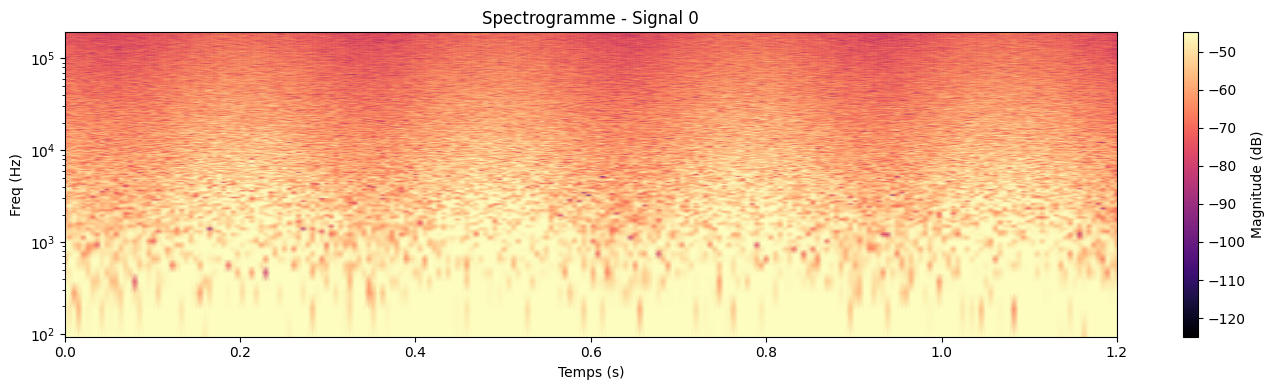

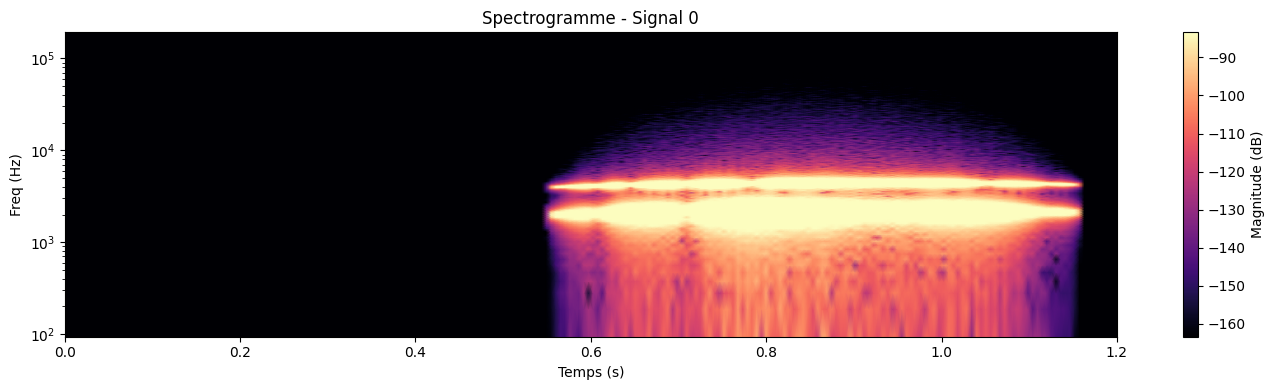

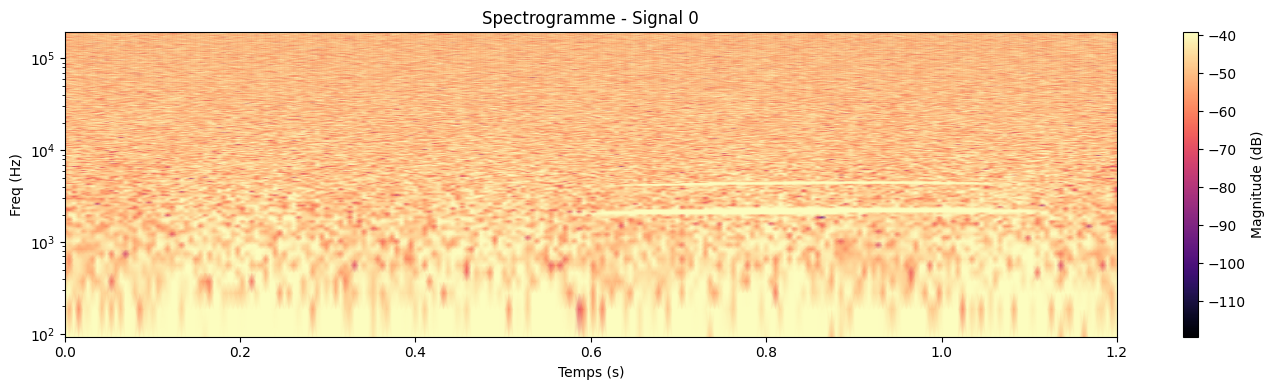

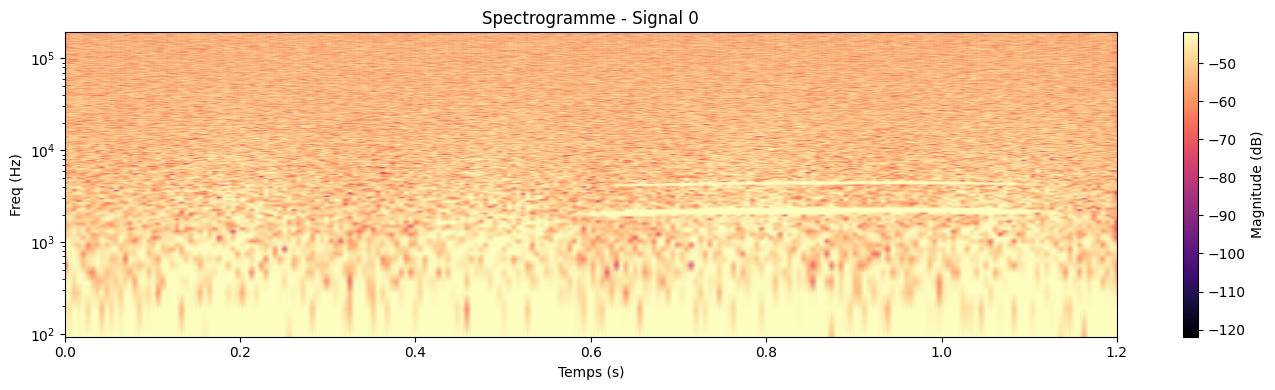

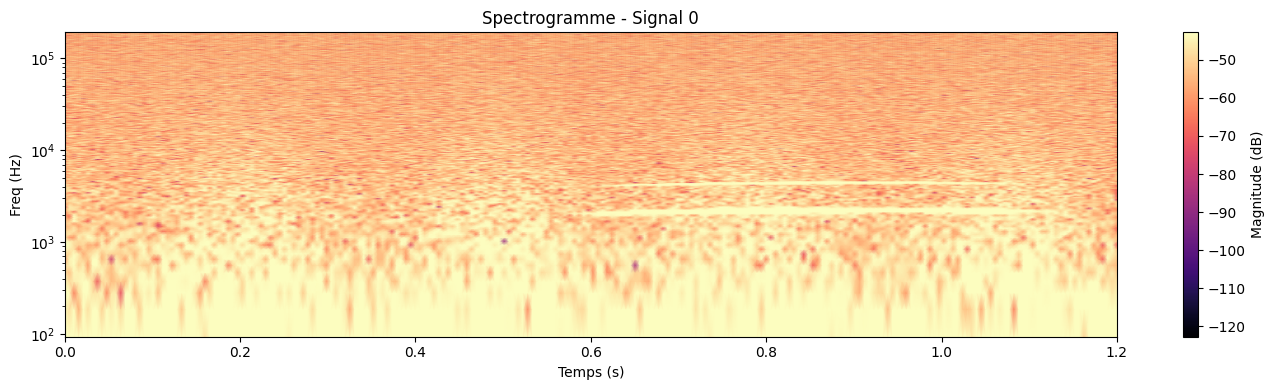

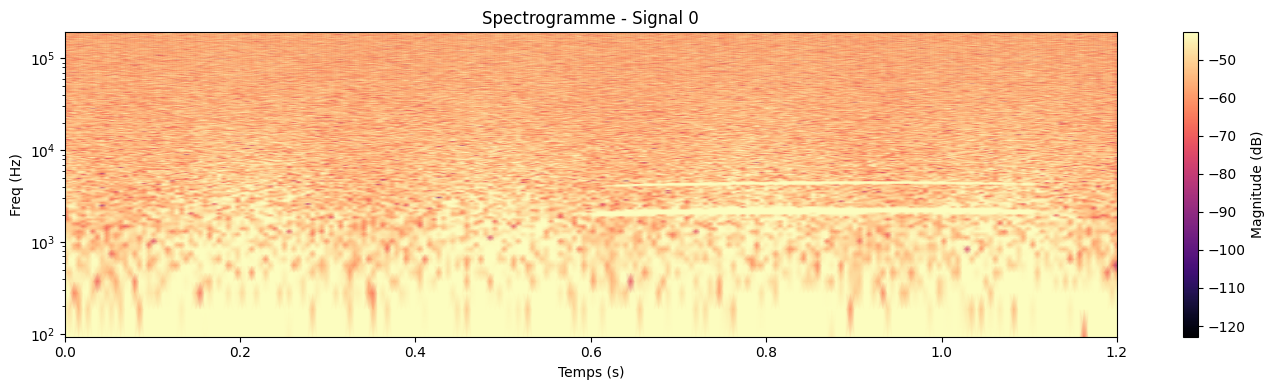

In [7]:
for source_index, signal in enumerate(scene.sources.signals):
    print(f'Spectrogramme de la source propre {source_index}')
    signal.plot_spectrogram(
        nperseg=4096,
        noverlap=2048,
        magnitude_scale='db',
        frequency_scale='log',
        figsize=(14, 4),
    )

for mic_index, signal in enumerate(scene.mixed.signals):
    print(f'Spectrogramme du microphone {mic_index}')
    signal.plot_spectrogram(
        nperseg=4096,
        noverlap=2048,
        magnitude_scale='db',
        frequency_scale='log',
        figsize=(14, 4),
    )

plt.show()

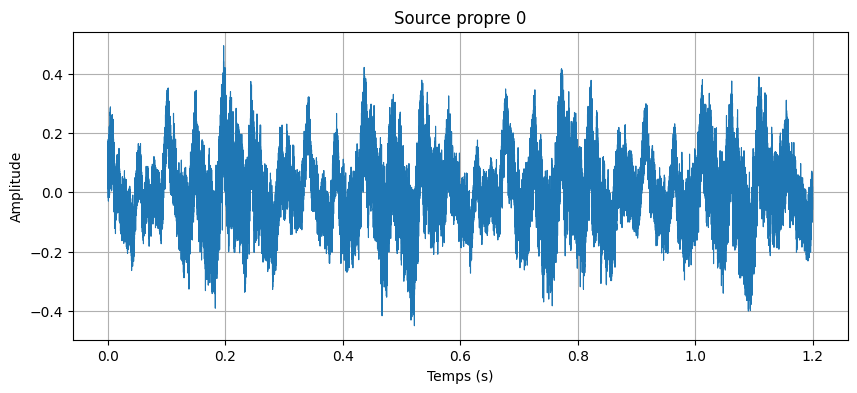

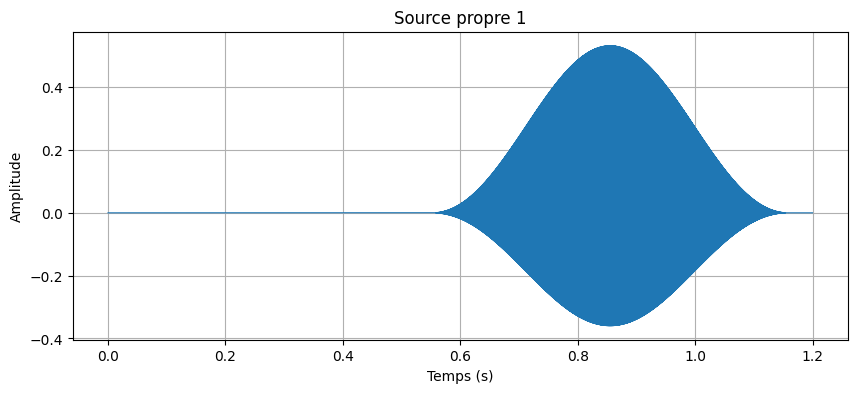

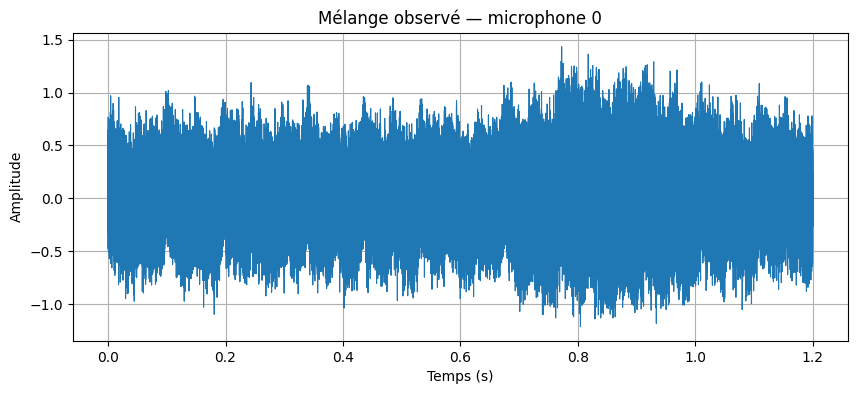

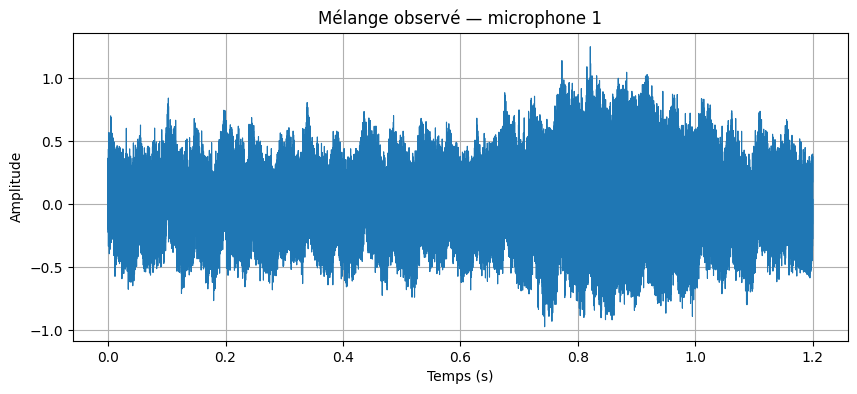

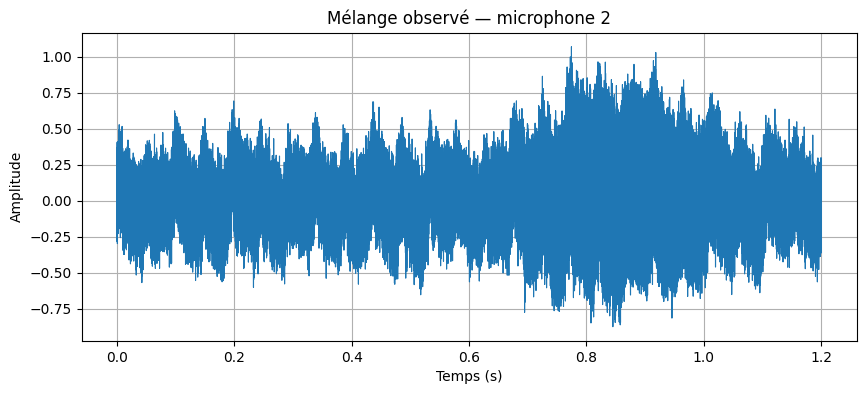

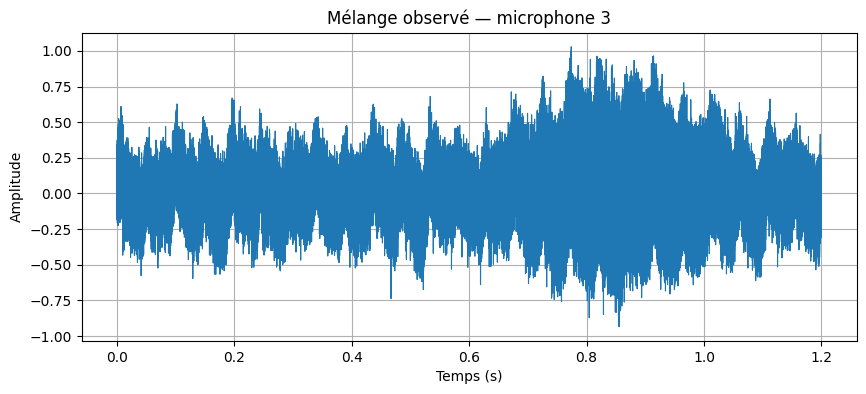

In [8]:
for source_index, signal in enumerate(scene.sources.signals):
    signal.plot(title=f'Source propre {source_index}', linewidth=0.8)

for mic_index, signal in enumerate(scene.mixed.signals):
    signal.plot(title=f'Mélange observé — microphone {mic_index}', linewidth=0.8)

plt.show()